# BC reconstruction method sensitivity (input-data uncertainty)

This notebook compares the model predictions for two different methods used to reconstruct the boundary conditions. The goal is to see how the uncertainty in the input data changes the predicted flood.

In [1]:
import sys, os

_proj_db = r'C:\Users\marrocol\AppData\Local\miniforge3\envs\mswe-gnn\Lib\site-packages\pyproj\proj_dir\share\proj'
os.environ.setdefault('PROJ_DATA', _proj_db)
os.environ.setdefault('PROJ_LIB',  _proj_db)

# Resolve the repo root robustly (works in VS Code and nbconvert, any start cwd)
try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    _here = os.getcwd()
    REPO_ROOT = _here if os.path.isdir(os.path.join(_here, 'database')) \
                else os.path.abspath(os.path.join(_here, '..'))
assert os.path.isdir(os.path.join(REPO_ROOT, 'database')), f'Not the repo root: {REPO_ROOT}'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import wandb
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from itertools import combinations

from utils.load import read_config
from utils.miscellaneous import get_model, fix_dict_in_config
from utils.dataset import create_model_dataset, get_temporal_test_dataset_parameters, to_temporal_dataset
from utils.visualization import PlotRollout
from training.train import LightningTrainer

torch.backends.cudnn.deterministic = True
torch.set_float32_matmul_precision('high')
print('Repo root:', REPO_ROOT)

Repo root: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg


## Datasets and checkpoint

In [2]:
CONFIG     = 'config_best_sweep.yaml'   # architecture auto-detected from checkpoint; 4-scale mesh
CHECKPOINT   = os.path.join(REPO_ROOT, 'results', 'best_sweep_bcaugment.h5')   # best_valloss

DATASETS = {
    'original': 'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart',
    'method1':  'ahr_river_v03_marg_method1_additionalsrc_velocity_100m_warmstart',
    'method2':  'ahr_river_v03_marg_method2_additionalsrc_velocity_100m_warmstart',
}

exists = os.path.exists(CHECKPOINT)
print(f"checkpoint exists={exists!s:<6}  {CHECKPOINT}")
for name, ds in DATASETS.items():
    p = f'database/datasets/test/{ds}.pkl'
    print(f"{name:<10} {ds:<52} exists={os.path.exists(p)}")

checkpoint exists=True    c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg\results\best_sweep_bcaugment.h5
original   ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart exists=True
method1    ahr_river_v03_marg_method1_additionalsrc_velocity_100m_warmstart exists=True
method2    ahr_river_v03_marg_method2_additionalsrc_velocity_100m_warmstart exists=True


## Build each dataset and run the (shared) model

In [3]:
device = torch.device('cpu')

def load_model_from_checkpoint(checkpoint_path, config, num_node_features, num_edge_features,
                                temporal_test_dataset_parameters, num_scales):
    model_parameters = dict(config.models)
    model_type = model_parameters.pop('model_type')
    if model_type == 'MSGNN':
        model_parameters['num_scales'] = num_scales

    ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    sd   = ckpt['state_dict']
    hid  = sd['model.edge_encoder.0.weight'].shape[0]

    proc_ids = sorted(set(
        int(k.split('.')[2]) for k in sd
        if k.startswith('model.gnn_processor.') and 'filter_matrix.' in k
    ))
    K_list = [
        sum(1 for k in sd if f'model.gnn_processor.{i}.filter_matrix.' in k and k.endswith('.weight')) - 1
        for i in proc_ids
    ]
    model_parameters['hid_features'] = hid
    model_parameters['K']            = K_list

    model = get_model(model_type)(
        num_node_features=num_node_features, num_edge_features=num_edge_features,
        previous_t=temporal_test_dataset_parameters['previous_t'], device=device,
        **model_parameters
    ).to(device)

    plmodule_kwargs = {
        'model': model, 'lr_info': config['lr_info'], 'trainer_options': config.trainer_options,
        'temporal_test_dataset_parameters': temporal_test_dataset_parameters
    }
    plmodule = LightningTrainer.load_from_checkpoint(checkpoint_path, map_location=device, **plmodule_kwargs)
    model = plmodule.model.to(device)
    model.eval()
    return model, hid, K_list


results = {}
model = None
for name, dataset_name in DATASETS.items():
    print(f'--- {name} ({dataset_name}) ---')
    cfg = read_config(CONFIG)
    cfg['dataset_parameters']['test_dataset_name']  = dataset_name
    cfg['dataset_parameters']['train_dataset_name'] = dataset_name
    wandb.init(mode='disabled', project='mswe-gnn', config=cfg, reinit=True)
    fix_dict_in_config(wandb)
    config = wandb.config

    _, _, test_dataset, scalers = create_model_dataset(
        scalers=config.scalers, device=device,
        **config.dataset_parameters, **config.selected_node_features, **config.selected_edge_features)
    ttdp = get_temporal_test_dataset_parameters(config, config.temporal_dataset_parameters)
    temporal_test_dataset = to_temporal_dataset(test_dataset, rollout_steps=-1, **ttdp)
    num_node_features = temporal_test_dataset[0].x.size(-1)
    num_edge_features = temporal_test_dataset[0].edge_attr.size(-1)

    if model is None:
        model, hid, K_list = load_model_from_checkpoint(
            CHECKPOINT, config, num_node_features, num_edge_features, ttdp, test_dataset[0].mesh.num_meshes)
        print(f'Loaded model: hid={hid} K={K_list}')

    plot_rollout = PlotRollout(model, test_dataset[0], scalers=scalers, warmup_steps=0, **ttdp)
    rl = plot_rollout._get_rollout_loss(type_loss='RMSE').mean(0)
    rmse_wd = rl[0].item() if rl.ndim > 0 else rl.item()
    csi005 = plot_rollout._get_CSI(water_threshold=0.05).nanmean().item()
    csi03  = plot_rollout._get_CSI(water_threshold=0.30).nanmean().item()

    results[name] = dict(plot_rollout=plot_rollout, rmse_wd=rmse_wd, csi_005=csi005, csi_03=csi03,
                          n_steps=plot_rollout.real_rollout.shape[-1])
    print(f'  RMSE_WD={rmse_wd:.4f}  CSI@0.05={csi005:.4f}  CSI@0.30={csi03:.4f}  '
          f'n_steps={results[name]["n_steps"]}')

--- original (ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart) ---
The validation dataset you are using is the training one. Careful!
Loaded model: hid=32 K=[1, 1, 1, 5, 4, 3, 2]
  RMSE_WD=0.1005  CSI@0.05=0.8527  CSI@0.30=0.8988  n_steps=118
--- method1 (ahr_river_v03_marg_method1_additionalsrc_velocity_100m_warmstart) ---
The validation dataset you are using is the training one. Careful!
  RMSE_WD=0.1139  CSI@0.05=0.8441  CSI@0.30=0.8904  n_steps=120
--- method2 (ahr_river_v03_marg_method2_additionalsrc_velocity_100m_warmstart) ---
The validation dataset you are using is the training one. Careful!
  RMSE_WD=0.1092  CSI@0.05=0.8452  CSI@0.30=0.8836  n_steps=120


## Reconstruction-method uncertainty estimate

In [4]:
header = f"{'method':<10} {'RMSE_WD':>9} {'CSI@0.05':>9} {'CSI@0.30':>9}"
print(header)
print('-' * len(header))
for name, r in results.items():
    print(f"{name:<10} {r['rmse_wd']:>9.4f} {r['csi_005']:>9.4f} {r['csi_03']:>9.4f}")

rmse_vals   = np.array([r['rmse_wd'] for r in results.values()])
csi005_vals = np.array([r['csi_005'] for r in results.values()])
csi03_vals  = np.array([r['csi_03']  for r in results.values()])

print(f"\nSpread across reconstruction methods (n={len(results)}):")
print(f"  RMSE_WD : mean={rmse_vals.mean():.4f} +- {rmse_vals.std(ddof=1):.4f}   "
      f"range [{rmse_vals.min():.4f}, {rmse_vals.max():.4f}]")
print(f"  CSI_005 : mean={csi005_vals.mean():.4f} +- {csi005_vals.std(ddof=1):.4f}   "
      f"range [{csi005_vals.min():.4f}, {csi005_vals.max():.4f}]")
print(f"  CSI_03  : mean={csi03_vals.mean():.4f} +- {csi03_vals.std(ddof=1):.4f}   "
      f"range [{csi03_vals.min():.4f}, {csi03_vals.max():.4f}]")

# Context: compare against the seed-uncertainty ruler (results/seed_table.csv), which captures
# training-randomness spread on a single fixed hydrograph. If the reconstruction-method spread is
# comparable to or larger than the seed ruler's spread, input-data uncertainty is at least as
# important a source of error as training variance.
try:
    import pandas as pd
    seed_table = pd.read_csv('results/seed_table.csv')
    ruler = seed_table[seed_table.ckpt == 'best_CSI']
    print(f"\nFor context, seed ruler (n={len(ruler)}, training-randomness only, single hydrograph):")
    print(f"  CSI_005 : mean={ruler.CSI_005.mean():.4f} +- {ruler.CSI_005.std(ddof=1):.4f}   "
          f"range [{ruler.CSI_005.min():.4f}, {ruler.CSI_005.max():.4f}]")
except FileNotFoundError:
    print('\n(results/seed_table.csv not found locally - skipping seed-ruler context)')

method       RMSE_WD  CSI@0.05  CSI@0.30
----------------------------------------
original      0.1005    0.8527    0.8988
method1       0.1139    0.8441    0.8904
method2       0.1092    0.8452    0.8836

Spread across reconstruction methods (n=3):
  RMSE_WD : mean=0.1079 +- 0.0068   range [0.1005, 0.1139]
  CSI_005 : mean=0.8473 +- 0.0047   range [0.8441, 0.8527]
  CSI_03  : mean=0.8910 +- 0.0076   range [0.8836, 0.8988]

For context, seed ruler (n=5, training-randomness only, single hydrograph):
  CSI_005 : mean=0.7609 +- 0.0419   range [0.7116, 0.8111]


## Does the model amplify or dampen the input uncertainty?

In [5]:
def rmse_between(a, b):
    T = min(a.shape[-1], b.shape[-1])
    return float(torch.sqrt(((a[..., :T] - b[..., :T]) ** 2).mean()))

header = f"{'pair':<22} {'truth-vs-truth RMSE':>20} {'pred-vs-pred RMSE':>18} {'ratio (pred/truth)':>19}"
print(header)
print('-' * len(header))
for n1, n2 in combinations(DATASETS.keys(), 2):
    r1, r2 = results[n1], results[n2]
    truth_rmse = rmse_between(r1['plot_rollout']._real_rollout_s0[:, 0, :], r2['plot_rollout']._real_rollout_s0[:, 0, :])
    pred_rmse  = rmse_between(r1['plot_rollout']._predicted_rollout_s0[:, 0, :], r2['plot_rollout']._predicted_rollout_s0[:, 0, :])
    ratio = pred_rmse / truth_rmse if truth_rmse else float('nan')
    print(f"{n1} vs {n2:<15} {truth_rmse:>20.4f} {pred_rmse:>18.4f} {ratio:>19.2f}")

pair                    truth-vs-truth RMSE  pred-vs-pred RMSE  ratio (pred/truth)
----------------------------------------------------------------------------------
original vs method1                       0.0837             0.0713                0.85
original vs method2                       0.0504             0.0997                1.98
method1 vs method2                       0.0516             0.0992                1.92


## Flood maps per method

--- original ---


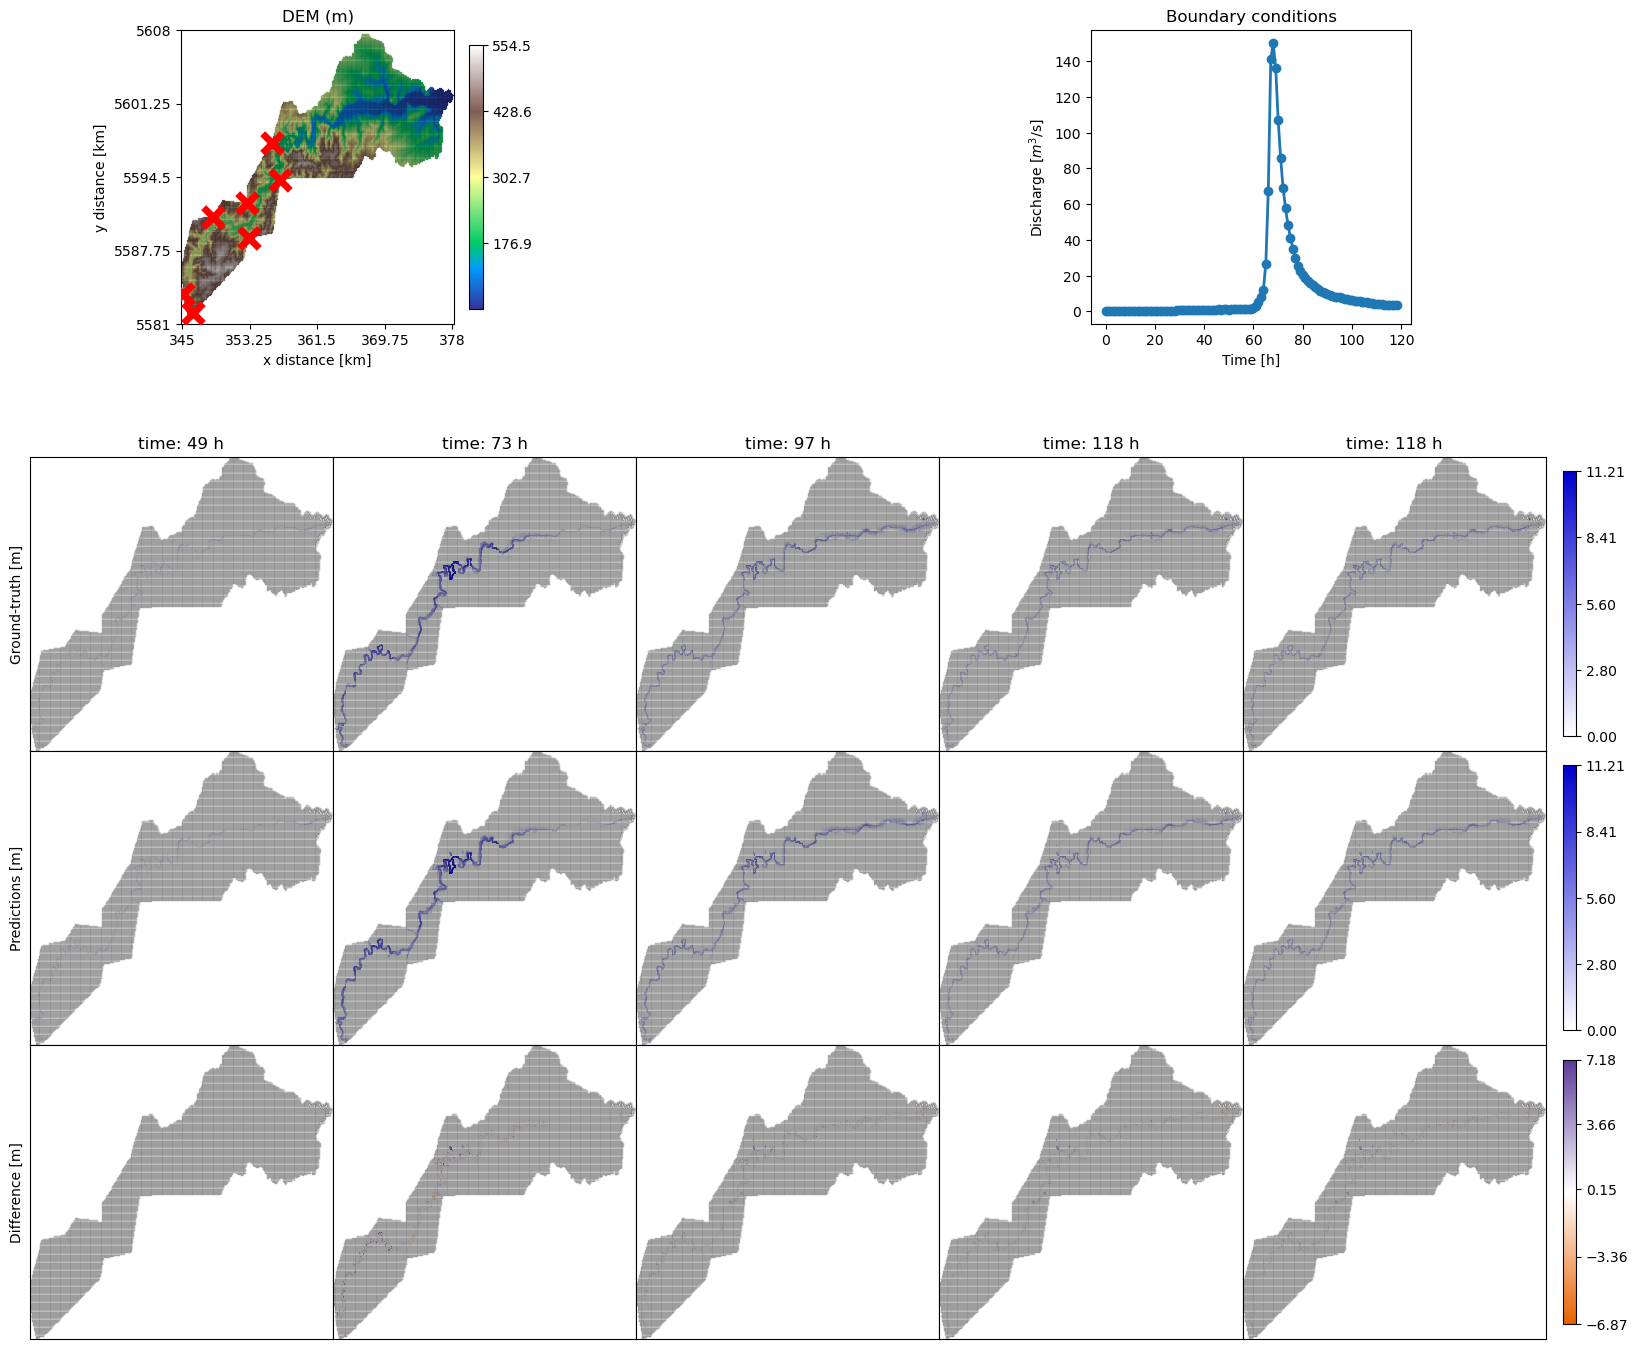

--- method1 ---


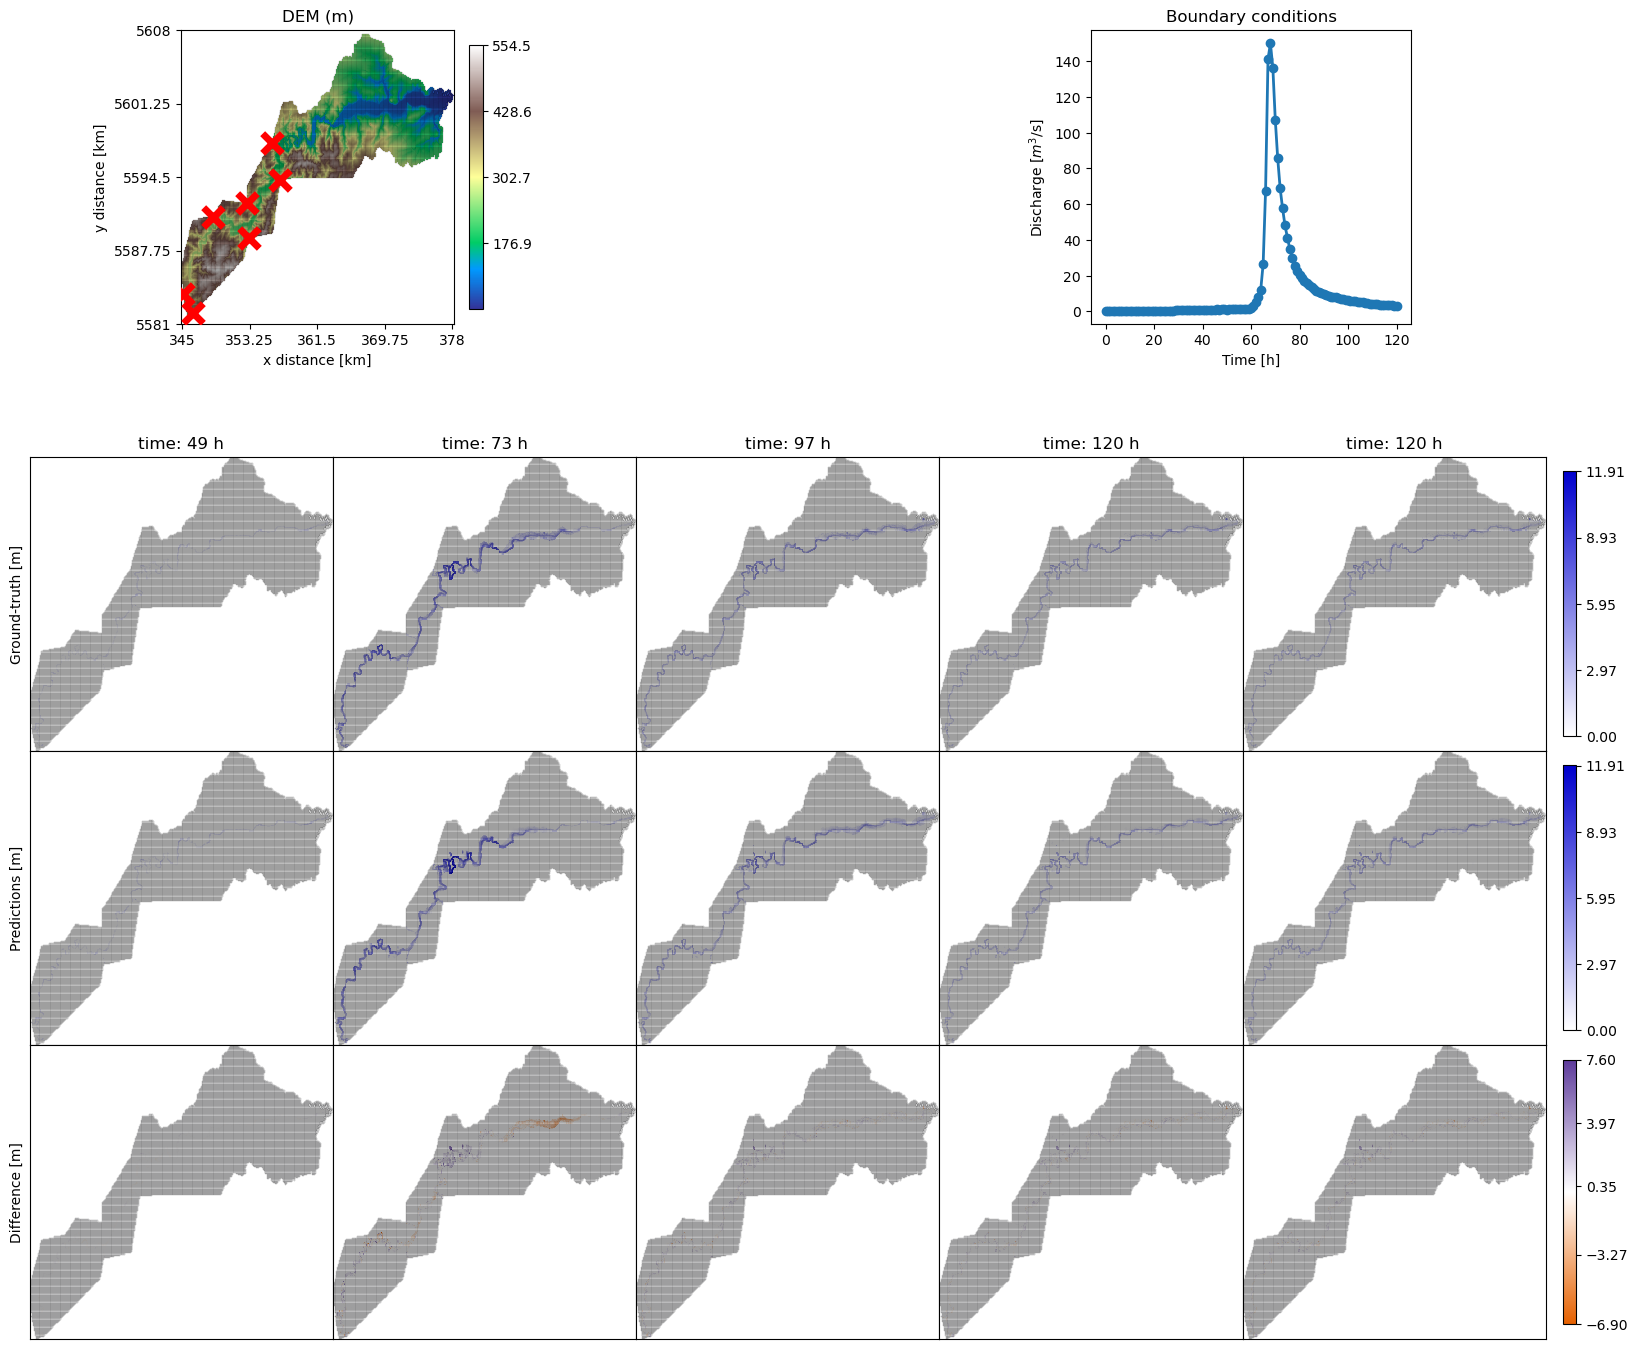

--- method2 ---


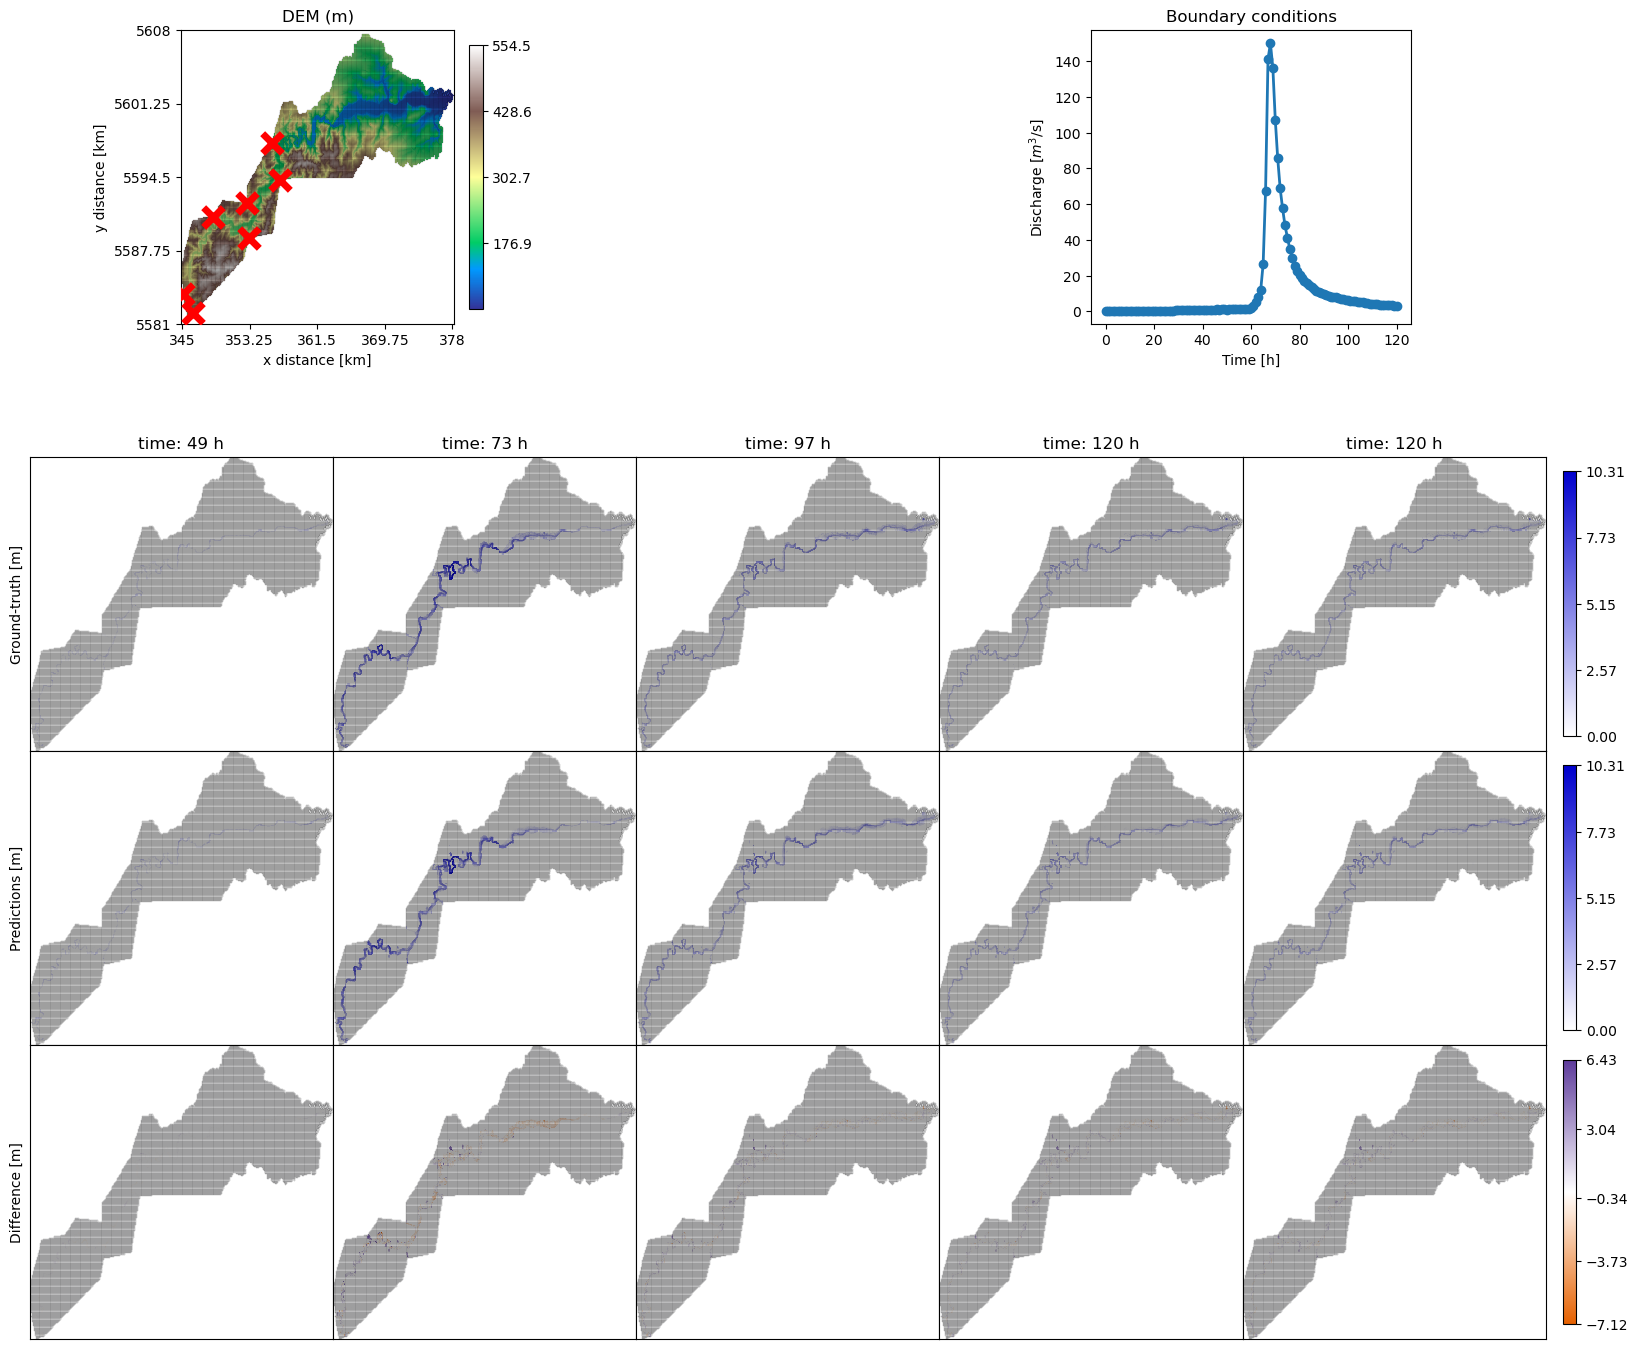

In [6]:
for name, r in results.items():
    print(f'--- {name} ---')
    pr = r['plot_rollout']
    n_steps = pr.real_rollout.shape[-1]
    plot_times = [48, 72, 96, n_steps - 1]
    pr.compare_h_rollout(plot_times=plot_times, scale=0)
    plt.show()

### Spatial difference between predictions

The validation dataset you are using is the training one. Careful!


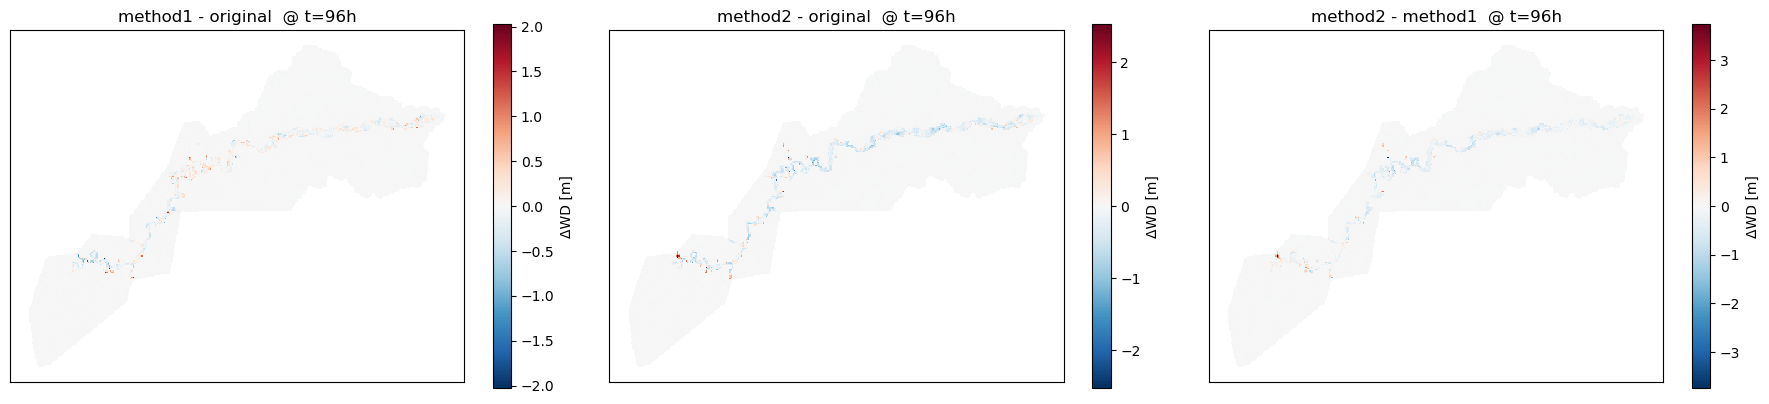

In [7]:
T_REF = 96
wd_by_method = {name: r['plot_rollout']._predicted_rollout_s0[:, 0, T_REF].cpu().numpy()
                for name, r in results.items()}

# mesh coordinates: any dataset works, same template for all three
cfg0 = read_config(CONFIG)
cfg0['dataset_parameters']['test_dataset_name']  = DATASETS['original']
cfg0['dataset_parameters']['train_dataset_name'] = DATASETS['original']
wandb.init(mode='disabled', project='mswe-gnn', config=cfg0, reinit=True)
fix_dict_in_config(wandb)
config0 = wandb.config
_, _, test_dataset0, _ = create_model_dataset(
    scalers=config0.scalers, device=device,
    **config0.dataset_parameters, **config0.selected_node_features, **config0.selected_edge_features)
n_s0 = wd_by_method['original'].shape[0]
pos_s0 = np.asarray(test_dataset0[0].mesh.face_xy)[:n_s0]

pairs = list(combinations(DATASETS.keys(), 2))
fig, axes = plt.subplots(1, len(pairs), figsize=(6 * len(pairs), 5.5))
if len(pairs) == 1:
    axes = [axes]
for ax, (n1, n2) in zip(axes, pairs):
    diff = wd_by_method[n2] - wd_by_method[n1]
    vmax = max(abs(diff.min()), abs(diff.max()), 1e-3)
    sc = ax.scatter(pos_s0[:, 0], pos_s0[:, 1], c=diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax, s=4, marker='s', linewidths=0)
    ax.set_title(f'{n2} - {n1}  @ t={T_REF}h')
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(sc, ax=ax, shrink=0.7, label='ΔWD [m]')
plt.tight_layout()
plt.show()